
# Problem Set 0 — Prior Knowledge Warm‑Up

**Goal.** This notebook helps you self‑check the prerequisite topics:
- Python / Jupyter / NumPy
- Linear Algebra
- Calculus
- Probability / Statistics
- Optimization (Convex function, Quadratic Program, KKT condition)
- LaTeX (math typesetting)

Each section has short tasks. Some cells include light tests. It's okay if you can't finish everything right away—use this to guide your review.

## 0) Jupyter notebook

# Different size of title
## Different size of title
### Different size of title
#### Different size of title

$$x^2$$

$$\begin{align}
    &\min_x f(x) \\
    s.t.~~~& g(x) = 0
\end{align}$$

In [3]:
# Data type
integar_a = 1
float_b = 1.5
string_c = "Hello"
print(integar_a, float_b, string_c)

1 1.5 Hello


In [6]:
# List
l = [integar_a, '123', [1, 2, 3, 4 ], 1 + 1j]
print(l)
print("The first element of list l is", l[0])
l.append(5)
print("After append, l is", l)

[1, '123', [1, 2, 3, 4], (1+1j)]
The first element of list l is 1
After append, l is [1, '123', [1, 2, 3, 4], (1+1j), 5]


In [8]:
# index
l = [0,1,2,3,4,5,6,7,8,9] 
print(l[2:5]) # [2, 3, 4]
print(l[2:])  # [2, 3, 4, 5, 6, 7, 8, 9]
print(l[:5])  # [0, 1, 2, 3, 4]
print(l[-3:]) # [7, 8, 9]
print(l[:-3]) # [0, 1, 2, 3, 4, 5, 6]
print(l[::2])   # [0, 2, 4, 6, 8]

[2, 3, 4]
[2, 3, 4, 5, 6, 7, 8, 9]
[0, 1, 2, 3, 4]
[7, 8, 9]
[0, 1, 2, 3, 4, 5, 6]
[0, 2, 4, 6, 8]



## 1) Python / Jupyter / NumPy

Warm‑up tasks to get comfortable with arrays, broadcasting, vectorization, and plotting.


In [9]:

# --- Setup & helpers (run this first) ---
import math
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(0)


In [10]:
#### CODING EXERCISES ####
# 1.a) Create a length‑5 NumPy array `a` with values [0, 1, 2, 3, 4] using vectorized construction (no loops).
# TODO: set a = ...
a = np.array([0, 1, 2, 3, 4], dtype=float)

# 1.b) Create another array `b` of the same length where b[i] = a[i]^2 (again, vectorized).
# TODO: set b = ...
b = a**2

# 1.c) Compute the dot product of `a` and `b` and store in `ab_dot`.
# TODO: set ab_dot = ...
ab_dot = a @ b

# 1.d) Use boolean indexing to select elements of `b` that are > 5. Store in `b_gt_5`.
# TODO: set b_gt_5 = ...
b_gt_5 = b[b > 5]

print(a, b, ab_dot, b_gt_5)


[0. 1. 2. 3. 4.] [ 0.  1.  4.  9. 16.] 100.0 [ 9. 16.]


In [ ]:
#### CODING EXERCISES ####
# 1.e) Plotting (Matplotlib only — no seaborn).
# TODO: Plot y = sin(x) for x in [0, 2π]. Create a single figure.
# Hint: Use np.linspace, plt.figure, plt.plot, plt.title
x = np.linspace(0, 2*np.pi, 300)
y = np.sin(x)

plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Sine wave: y = sin(x)")
plt.grid(True)
plt.show()



## 2) Linear Algebra

**Topics:** norms, matrix multiplication, eigen/SVD, least squares.


#### Norms
Let $V$ be a vector space (e.g. $\mathbb{R}^n$ or $\mathbb{C}^n$).  
A function
$$\|\cdot\| : V \to [0,\infty)$$
is called a **norm** on $V$ if for all $\mathbf{x}, \mathbf{y} \in V$ and scalars $\alpha$, the following hold:

1. **Non-negativity and definiteness** 
   $$\|\mathbf{x}\| \geq 0, 
   \quad \|\mathbf{x}\| = 0 \iff \mathbf{x} = \mathbf{0}$$

2. **Homogeneity**  
   $$\|\alpha \mathbf{x}\| = |\alpha| \, \|\mathbf{x}\|$$

3. **Triangle inequality**  
   $$\|\mathbf{x} + \mathbf{y}\| \leq \|\mathbf{x}\| + \|\mathbf{y}\|$$

A common class of norms are the $\ell_p$ norms, defined as
$$
\|\mathbf{x}\|_p = \left( \sum_{i=1}^n |x_i|^p \right)^{1/p}, \quad (1 \leq p < \infty),
$$
and
$$
\|\mathbf{x}\|_\infty = \max_{1 \leq i \leq n} |x_i|.
$$

PAPER and PEN EXERCISES

2.a) **$\textcolor{blue}{\text{TODO}}$**: Give the formulation of $l_2$ norm of a vector $x = [x_1,x_2,x_3,x_4,x_5]$

$\|x\|_2 = $

2.b) Give the $l_2$ norm of a vector $y = [1,3,5,7,9]$

$\|y\|_2 = $

In [ ]:
#### CODING EXERCISES ####
# 2.c) Norms in numpy （Hint: np.linalg.norm）
x = np.array([1,2,3,4,5])
x_norm= np.linalg.norm(x)

#### Matrix Operations

A **matrix** is a rectangular array of numbers with $m$ rows and $n$ columns.  
For example, $A \in \mathbb{R}^{m \times n}$ can be written as
$$
A =
\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{bmatrix}.
$$

- **Addition**: If $A, B \in \mathbb{R}^{m \times n}$, then
$$
A + B = (a_{ij} + b_{ij})_{m \times n}.
$$

- **Scalar multiplication**: For $\alpha \in \mathbb{R}$,
$$
\alpha A = (\alpha \cdot a_{ij})_{m \times n}.
$$

- **Matrix multiplication**: If $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{n \times p}$, then
$$
C = AB \in \mathbb{R}^{m \times p}, \quad c_{ij} = \sum_{k=1}^n a_{ik} b_{kj}.
$$


In [11]:
#### CODING EXERCISES ####
# 2.d) Matrix multiplication in numpy
A = np.array([[1, 2],
              [3, 4]])

B = np.array([[5, 6],
              [7, 8]])

# TODO: C = AB
C = A @ B
print("AB =\n", C)


AB =
 [[19 22]
 [43 50]]


#### Eigenvalues and Eigenvectors

Let $A \in \mathbb{R}^{n \times n}$ be a square matrix.  
A scalar $\lambda \in \mathbb{R}$ is called an **eigenvalue** of $A$ if there exists a nonzero vector $\mathbf{v} \in \mathbb{R}^n$ such that
$$
A \mathbf{v} = \lambda \mathbf{v}.
$$
Here, $\mathbf{v}$ is called an **eigenvector** corresponding to $\lambda$.


PAPER and PEN EXERCISES

2.e) **$\textcolor{blue}{\text{TODO}}$**: Give an eigenvalue and corresponding eigenvector of matrix 

$A = \begin{bmatrix}1 & 2 \\ 2 & 1\end{bmatrix}$.

$\lambda =$

$v = $ 

In [ ]:
#### CODING EXERCISES ####
# 2.f) Eigen value in numpy
A = np.array([[2, 1],
              [1, 2]])

eigvals, eigvecs = np.linalg.eig(A)

print("Eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)

#### Positive Semidefinite (PSD) Matrices

**Definition.** A symmetric matrix $A\in\mathbb{R}^{n\times n}$ is **positive semidefinite (PSD)** if
$$
\mathbf{x}^\top A\,\mathbf{x}\ \ge 0\quad \text{for all }\mathbf{x}\in\mathbb{R}^n.
$$
It is **positive definite (PD)** if the inequality is strict for all $\mathbf{x}\ne \mathbf{0}$.

**Equivalent characterizations (PSD).**
- All eigenvalues of $A$ are nonnegative: $\lambda_i(A)\ge 0$.
- $A$ is a Gram matrix: there exists $B\in\mathbb{R}^{m\times n}$ with $A=B^\top B$.
- All principal submatrices of a PSD matrix are PSD.

#### PAPER and PEN EXERCISES

2.g) **$\textcolor{blue}{\text{TODO}}$**:
$$
A=\begin{bmatrix}2&-1\\-1&2\end{bmatrix},\quad
B=\begin{bmatrix}1&0&0\\0&0&0\\0&0&2\end{bmatrix},\quad
$$
- (g.1) Compute eigenvalues of each matrix and decide PSD/PD/indefinite.  
- (g.2) For $B$, verify directly that $\mathbf{x}^\top B\,\mathbf{x}\ge 0$ for all $\mathbf{x}$.



## 3) Calculus

**Topics:** gradients, Hessians;


#### Gradient & Hessian 

- **Gradient.** For a differentiable scalar field $f: \mathbb{R}^n\to\mathbb{R}$,
$$
\nabla f(\mathbf{x})=
\begin{bmatrix}
\frac{\partial f}{\partial x_1}(\mathbf{x})\\
\vdots\\
\frac{\partial f}{\partial x_n}(\mathbf{x})
\end{bmatrix},
\qquad

$$

- **Hessian.** If second partials exist,
$$
\nabla^2 f(\mathbf{x})=\left[\frac{\partial^2 f}{\partial x_i\,\partial x_j}(\mathbf{x})\right]_{i,j=1}^n.
$$


PAPER and PEN EXERCISES

3.a) **$\textcolor{blue}{\text{TODO}}$**: For $f(\mathbf{x})=\tfrac12\,\mathbf{x}^\top A\,\mathbf{x}+\mathbf{b}^\top\mathbf{x}+c$ with symmetric \(A\),
$$
\nabla f(\mathbf{x})= Ax + b
$$
$$
\nabla^2 f(\mathbf{x})= A
$$

#### Convex Functions

**Definition (convex).** Let $f:\mathbb{R}^n\to(-\infty,+\infty]$ with a **convex domain** $D$
 
$f$ is **convex** if for all $x,y\in D$ and $t\in[0,1]$,
$$
f(tx+(1-t)y)\ \le\ t\,f(x)+(1-t)\,f(y).
$$
It is **strictly convex** if the inequality is strict whenever $x\neq y$ and $t\in(0,1)$.

**Second-order condition ($C^2$ on a convex domain).** $f$ is convex iff
$$
\nabla^2 f(x)\ \succeq\ 0\quad \text{for all }x\in D.
$$


PAPER and PEN EXERCISES

3.b) **$\textcolor{blue}{\text{TODO}}$**: Show the condition when $f(\mathbf{x})=\tfrac12\,\mathbf{x}^\top A\,\mathbf{x}+\mathbf{b}^\top\mathbf{x}+c$ is convex.

$$
\nabla^2 f(\mathbf{x})= A \succeq\ 0
$$


## 4) Statistic

**Topics:** Normal & Uniform distribution, Expectation, Variance

#### Basic definition
- **Expectation (mean).**  
Discrete: 
$$
\mathbb{E}[X]=\sum_x x\,\mathbb{P}(X=x)
$$
Continuous:
$$
\mathbb{E}[X]=\int_{-\infty}^{\infty} x\,f_X(x)\,dx
$$

- **Variance.**
$$
\operatorname{Var}(X)=\mathbb{E}\!\left[(X-\mathbb{E}[X])^2\right]
=\mathbb{E}[X^2]-\big(\mathbb{E}[X]\big)^2.
$$

- **Normal (Gaussian) distribution.** Define $X\sim \mathcal{N}(\mu,\sigma^2)$:
$$
f(x)=\frac{1}{\sqrt{2\pi}\,\sigma}\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),\qquad
\mathbb{E}[X]=\mu,\quad \operatorname{Var}(X)=\sigma^2.
$$

- **Uniform distribution on \([a,b]\).** Define $X\sim \mathcal{U}(a,b)$,
$$
f(x)=\frac{1}{b-a}\quad (a\le x\le b),\qquad
\mathbb{E}[X]=\frac{a+b}{2},\quad
\operatorname{Var}(X)=\frac{(b-a)^2}{12}.
$$

In [ ]:
#### CODING EXERCISES ####
# 4.a) TODO: Normal distribution

# Normal N(mu, sigma^2) (Hint: np.random.normal)
mu, sigma = 2.0, 3.0
z = np.random.normal(loc=mu, scale=sigma, size=100000)
print("Normal sample mean/var ~", z.mean(), z.var())

# 4.b) TODO: Uniform distribution 

# Uniform U(a, b) (Hint: np.random.uniform)
a, b = -1.0, 5.0
u = np.random.uniform(low=a, high=b, size=100000)
print("Uniform sample mean/var ~", u.mean(), u.var())

# Theoretical checks
print("Normal theory mean/var =", mu, sigma**2)
print("Uniform theory mean/var =", (a+b)/2, (b-a)**2/12)


#### Bayes' Theorem

**Statement** For events $A$ and $B$ with $\mathbb{P}(B)>0$,
$$
\mathbb{P}(A\mid B)=\frac{\mathbb{P}(B\mid A)\,\mathbb{P}(A)}{\mathbb{P}(B)}.
$$
Here, $\mathbb{P}(A)$ is the **prior**, $\mathbb{P}(B\mid A)$ the **likelihood**, $\mathbb{P}(A\mid B)$ the **posterior**, and $\mathbb{P}(B)$ the **evidence**.

**Total probability** If $\{H_i\}$ is a partition of the sample space,
$$
\mathbb{P}(B)=\sum_i \mathbb{P}(B\mid H_i)\,\mathbb{P}(H_i).
$$


PAPER and PEN EXERCISES

4.c) **$\textcolor{blue}{\text{TODO}}$**:

You pick one of two boxes at random (each with probability $1/2$):
- Box $A$: $3$ red ball, $1$ blue ball.
- Box $B$: $1$ red ball, $3$ blue ball.

You then draw one ball and observe it is red. What is $\mathbb{P}(A \mid \text{red})$?


- $\mathbb{P}(A)=\tfrac12,\quad \mathbb{P}(B)=\tfrac12$  
- $\mathbb{P}(\text{red}\mid A)=\tfrac34,\quad \mathbb{P}(\text{red}\mid B)=\tfrac14$  
- $\mathbb{P}(\text{red})=\tfrac12(\tfrac34+\tfrac14)=\tfrac12$  
- $\mathbb{P}(A\mid \text{red})=\dfrac{\tfrac34\cdot\tfrac12}{\tfrac12}=\tfrac34=0.75$



## 5) Optimization

**Topics:** cvxpy, KKT condition.

#### Linear Programming Example

We want to solve the following linear program:

$$
\begin{aligned}
\max_{x,y}\quad & x + y \\
\text{s.t.}\quad 
& x + 2y \leq 4, \\
& 2x + y \leq 6, \\
& x \geq 0,\ y \geq 0.
\end{aligned}
$$


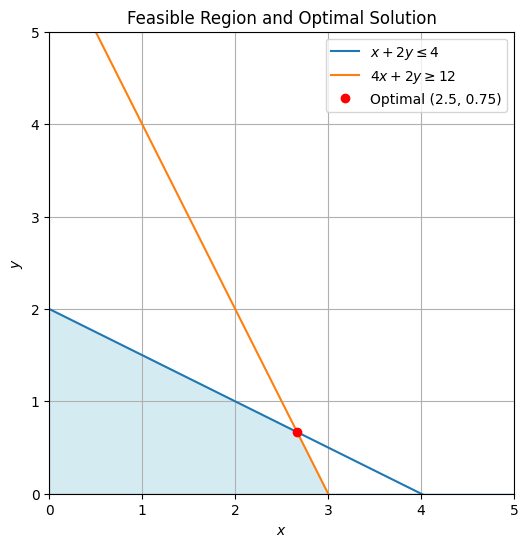

In [16]:
# visualization
x = np.linspace(0, 5, 200)

y1 = (4 - x) / 2
y2 = 6 - 2*x

# Feasible region: intersection
plt.figure(figsize=(6,6))

# Plot constraint lines
plt.plot(x, y1, label=r"$x+2y \leq 4$")
plt.plot(x, y2, label=r"$2x+y \geq 6$")

# Fill feasible region
y_upper = np.minimum(y1, y2)
y_upper = np.maximum(y_upper, 0)  # ensure non-negative
plt.fill_between(x, 0, y_upper, where=(y_upper>=0), color="lightblue", alpha=0.5)

# Mark optimal point (from CVXPY solution)
opt_x, opt_y = 8/3, 2/3
plt.plot(opt_x, opt_y, "ro", label="Optimal")

# Labels and formatting
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Feasible Region and Optimal Solution")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
import cvxpy as cp

#### CODING EXERCISES ####

# 4.a) TODO: Define variables
# Variables
x = cp.Variable()
y = cp.Variable()

# 4.b) TODO: Define objectives
# Objective: maximize x + y
objective = cp.Maximize(x + y)

# 4.c) TODO: Define constraints
# Constraints:
# x + 2y <= 4
# 4x + 2y <= 12
# x >= 0, y >= 0
constraints = [
    x + 2*y <= 4,
    4*x + 2*y <= 12,
    x >= 0,
    y >= 0
]

# Problem definition
problem = cp.Problem(objective, constraints)

# Solve
problem.solve()

print("status:", problem.status)
print("optimal value:", problem.value)
print("optimal (x,y):", x.value, y.value)

status: optimal
optimal value: 3.333333332201236
optimal (x,y): 2.6666666676628243 0.6666666645384114


#### KKT condition

You don't need to fully understand but learn to use it as a tool.

The **Karush–Kuhn–Tucker (KKT) conditions** are necessary conditions for a solution $x^*$ to be optimal in a constrained optimization problem of the form:

$$
\begin{aligned}
\min_{x}\quad & f(x) \\
\text{s.t.}\quad & g_i(x) \leq 0,\quad i=1,\dots,m, \\
& h_j(x) = 0,\quad j=1,\dots,p.
\end{aligned}
$$

**KKT conditions** (assuming regularity conditions hold):

1. **Primal feasibility**  
   $$
   g_i(x^*) \leq 0, \quad h_j(x^*) = 0
   $$

2. **Dual feasibility**  
   $$
   \lambda_i \geq 0, \quad i=1,\dots,m
   $$

3. **Stationarity**  
   $$
   \nabla f(x^*) + \sum_{i=1}^m \lambda_i \nabla g_i(x^*) + \sum_{j=1}^p \mu_j \nabla h_j(x^*) = 0
   $$

4. **Complementary slackness**  
   $$
   \lambda_i g_i(x^*) = 0, \quad i=1,\dots,m
   $$

Here:
- $\lambda_i$ is defined as **Lagrange multipliers** for inequality constraints.
- $\mu_j$ is defined as **Lagrange multipliers** for equality constraints.

PAPER and PEN EXERCISES

5. a) **$\textcolor{blue}{\text{TODO}}$**: Solve KKT by hand

We solve
$$
\begin{aligned}
\min_{x\in\mathbb{R}^2}\quad & f(x)=x^\top x + c^\top x,\quad c=\begin{bmatrix}-2\\-6\end{bmatrix} \\
\text{s.t.}\quad & a^\top x \le 3,\quad a=\begin{bmatrix}1\\1\end{bmatrix},\\
& x \ge 0
\end{aligned}
$$

**KKT (by hand).** Lagrangian:
$$
L(x,\mu,\nu)=x^\top x + c^\top x + \mu(a^\top x-3) - \nu^\top x,
$$
where $\mu\in\mathbb{R}$ is the multiplier for the equality and $\nu\ge 0$ for $x\ge 0$.
1. **Stationarity:**  
   $$
   2x + c + \mu a - \nu = 0
   $$

2. **Primal feasibility:**  
   $$
   a^\top x = 3, \quad x \ge 0
   $$

3. **Dual feasibility:**  
   $$
   \nu \ge 0
   $$

4. **Complementary slackness:**  
   $$
   \nu_i x_i = 0, \quad i=1,2.
   $$


**Derivation.**  
From stationarity $2x + c + \mu a - \nu = 0$, we have $\nu = 2x + c + \mu a$.  
Multiplying by $x$ componentwise gives
$$
\nu^\top x =
\begin{bmatrix}
2x_1^2 - 2x_1 + \mu x_1 \\
2x_2^2 - 6x_2 + \mu x_2
\end{bmatrix} = 0.
$$

Thus
$$
x_1 = 0 \quad\text{or}\quad x_1 = \tfrac{2-\mu}{2}, \qquad
x_2 = 0 \quad\text{or}\quad x_2 = \tfrac{6-\mu}{2}.
$$

From the equality $a^\top x = x_1+x_2=3$:  

- If $x_1=0$, then $x_2=3,\ \mu=0$, giving $\nu_1=2x_1-2+\mu=-2<0$ (violates dual feasibility).  
- If $x_2=0$, then $x_1=3,\ \mu=-4$, giving $\nu_2=2x_2-6+\mu=-10<0$ (violates dual feasibility).  

So the only valid case is  
$$
x_1=\tfrac{2-\mu}{2},\quad x_2=\tfrac{6-\mu}{2}.
$$
From $x_1+x_2=3$ we get $\mu=1$, hence $x_1=0.5,\ x_2=2.5$.  

$$
x^\star=\begin{bmatrix}
0.5 \\
2.5
\end{bmatrix}
$$


In [18]:
#### CODING EXERCISES ####
# 5/ b) Verify using cvxpy
c = np.array([-2.0, -6.0])
a = np.array([1.0, 1.0])

x = cp.Variable(2)
con_eq = a @ x == 3
con_nn = x >= 0
prob = cp.Problem(cp.Minimize(cp.sum_squares(x) + c @ x), [con_eq, con_nn])
prob.solve()

x_cvx = x.value
mu = con_eq.dual_value     # equality multiplier
nu = con_nn.dual_value     # inequality multipliers

print("status:", prob.status)
print("x* (cvxpy):", x_cvx)

status: optimal
x* (cvxpy): [0.5 2.5]



## 6) Gym environment

Just have fun interacting with gym!

In [21]:
# FrozenLake interactive UI (Gymnasium + ipywidgets + matplotlib)
import numpy as np
import matplotlib.pyplot as plt

# Prefer gymnasium; fallback to gym if needed
try:
    import gymnasium as gym
except ImportError:
    import gym

import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- Build environment (deterministic for student control) ----
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)  # render via our own plot
obs, info = env.reset(seed=42)

# ---- Helpers to draw the grid nicely ----
def _colors(desc):
    """Return a color grid for imshow based on desc bytes (F, H, S, G)."""
    # Map tiles to numeric codes for a colormap
    # F=1 (ice), H=0 (hole), S=2 (start), G=3 (goal)
    code_map = {b'H': 0, b'F': 1, b'S': 2, b'G': 3}
    grid = np.vectorize(lambda b: code_map[b])(desc)
    return grid

def draw_board(ax, desc, s):
    nrow, ncol = desc.shape
    grid = _colors(desc)
    # Build a simple colormap
    # 0 hole (black), 1 ice (light blue), 2 start (green), 3 goal (gold)
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap([
        (0,0,0),            # hole
        (0.7,0.85,1.0),     # ice
        (0.2,0.7,0.2),      # start
        (1.0,0.84,0.0)      # goal
    ])

    ax.imshow(grid, cmap=cmap, vmin=0, vmax=3)
    ax.set_xticks(np.arange(-0.5, ncol, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrow, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.set_xticks([])
    ax.set_yticks([])

    # Draw agent as a red dot at state s
    r, c = divmod(int(s), ncol)
    ax.plot(c, r, marker="o", markersize=18, markeredgecolor="white", markerfacecolor="red")

def get_desc(env):
    # env.unwrapped.desc is a 2D array of bytes
    return env.unwrapped.desc

# ---- Widget UI ----
btn_left  = widgets.Button(description="⬅ Left (0)",  layout=widgets.Layout(width="120px"))
btn_down  = widgets.Button(description="⬇ Down (1)",  layout=widgets.Layout(width="120px"))
btn_right = widgets.Button(description="➡ Right (2)", layout=widgets.Layout(width="120px"))
btn_up    = widgets.Button(description="⬆ Up (3)",    layout=widgets.Layout(width="120px"))
btn_reset = widgets.Button(description="🔄 Reset",     button_style="warning", layout=widgets.Layout(width="120px"))
btn_random= widgets.Button(description="🎲 Random",    layout=widgets.Layout(width="120px"))

out = widgets.Output()
status = widgets.HTML(value="Episode started. Use the buttons to move.")
score_label = widgets.HTML(value="Return: 0.0")
box = widgets.HBox([btn_left, btn_down, btn_right, btn_up, btn_reset, btn_random])

display(widgets.VBox([box, status, score_label, out]))

# Track episode return and done flag
episode_return = 0.0
done = False

def render_now():
    """Render the current board in the output cell."""
    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(4,4))
        desc = get_desc(env)
        # Current agent state (integer) is env.unwrapped.s
        s = env.unwrapped.s
        draw_board(ax, desc, s)
        plt.title("FrozenLake-v1 (4x4)")
        plt.tight_layout()
        plt.show()

def step_env(action):
    global episode_return, done, obs
    if done:
        status.value = "<b>Episode is done.</b> Click <em>Reset</em> to start again."
        return
    step = env.step(action)
    if len(step) == 5:
        obs, reward, terminated, truncated, info = step
        done = bool(terminated or truncated)
    else:
        obs, reward, done, info = step
    episode_return += float(reward)
    score_label.value = f"Return: {episode_return:.2f}"
    if done:
        status.value = f"<b>Episode finished.</b> Reward: {reward}. Click <em>Reset</em>."
    else:
        status.value = f"Moved with action {action}."
    render_now()

def on_left(_):  step_env(0)  # Left
def on_down(_):  step_env(1)  # Down
def on_right(_): step_env(2)  # Right
def on_up(_):    step_env(3)  # Up
def on_reset(_):
    global obs, episode_return, done
    obs, info = env.reset()
    episode_return = 0.0
    done = False
    status.value = "Episode reset."
    score_label.value = "Return: 0.0"
    render_now()

def on_random(_):
    # Take a random action (useful to demonstrate transitions)
    action = env.action_space.sample()
    step_env(action)

btn_left.on_click(on_left)
btn_down.on_click(on_down)
btn_right.on_click(on_right)
btn_up.on_click(on_up)
btn_reset.on_click(on_reset)
btn_random.on_click(on_random)

# Initial draw
render_now()
